In [23]:
import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt
from arch import arch_model

from config import RAW_DATA_DIR
from core.models import (IIDNormalModel, IIDStudentTModel, IIDNonNormalModel, AR1NormalModel,
        AR1NonNormalModel, GARCH11Model, AR1GARCH11NormalModel, AR1GARCH11SymmModel, AR1GARCH11Model)
from core.hierarchical_model_sel import hierarchical_analysis

In [24]:
prices = pd.read_csv(
    RAW_DATA_DIR / "SPDR_WE.csv",
    parse_dates=["Date"], index_col="Date"
)
prices = prices.loc[:, ~prices.columns.str.contains("^Unnamed")]

prices = prices.sort_index()
prices.describe()

,XLK,XLF,XLV,XLE,XLY,XLP,XLRE,SPTL,GLD,SPIP
count,523.000000,523.000000,523.000000,523.000000,523.000000,523.000000,523.000000,523.000000,523.000000,523.000000
mean,63.567380,32.518317,110.451912,34.549465,71.749082,65.596424,37.395010,34.975124,25.983824,27.885258
std,33.731731,9.482523,27.215558,8.319281,22.949211,10.417656,5.038957,6.147291,12.663092,1.874107
min,19.640000,16.640000,63.950000,12.930000,34.900000,48.300000,27.160000,24.670000,8.200000,24.420000
25%,34.025000,25.375000,85.380000,29.300000,52.555000,55.010000,32.925000,29.105000,16.980000,26.095000
50%,61.870000,30.770000,113.000000,33.990000,71.490000,66.150000,37.050000,34.930000,19.900000,27.920000
75%,84.215000,38.050000,133.815000,42.325000,89.050000,74.830000,41.040000,39.535000,32.120000,28.880000
max,150.340000,55.620000,157.650000,49.040000,122.050000,83.930000,51.810000,48.860000,58.230000,31.810000


In [71]:
prices

,XLK,XLF,XLV,XLE,XLY,XLP,XLRE,SPTL,GLD,SPIP
Date,,,,,,,,,,
2016-01-01,21.42,19.35,71.56,29.28,39.08,50.49,31.18,34.94,17.14,27.32
2016-01-08,20.05,17.95,67.58,27.21,36.81,49.02,30.11,35.69,17.07,27.50
2016-01-15,19.67,17.39,66.44,26.39,35.75,48.30,29.25,36.36,16.25,27.47
2016-01-22,20.19,17.28,67.41,27.06,36.66,49.29,29.48,36.25,18.44,27.41
2016-01-29,20.62,17.64,66.04,28.26,37.06,50.76,29.19,36.77,15.72,27.81
...,...,...,...,...,...,...,...,...,...,...
2025-12-05,146.60,53.68,153.26,45.92,119.73,78.46,40.99,26.66,44.84,26.09
2025-12-12,143.69,54.95,154.06,45.51,120.70,79.42,40.75,26.45,43.81,26.03
2025-12-19,144.60,54.84,154.94,44.13,121.85,78.78,40.33,26.49,43.21,25.94


In [70]:
prices.index

DatetimeIndex(['2016-01-01', '2016-01-08', '2016-01-15', '2016-01-22',
               '2016-01-29', '2016-02-05', '2016-02-12', '2016-02-19',
               '2016-02-26', '2016-03-04',
               ...
               '2025-10-31', '2025-11-07', '2025-11-14', '2025-11-21',
               '2025-11-28', '2025-12-05', '2025-12-12', '2025-12-19',
               '2025-12-26', '2026-01-02'],
              dtype='datetime64[us]', name='Date', length=523, freq=None)

<Axes: xlabel='Date'>

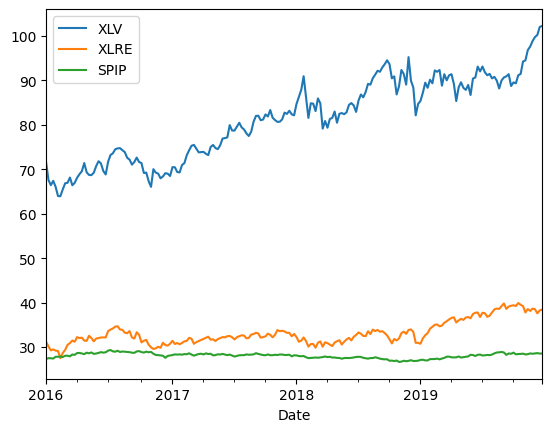

In [25]:
prices.loc["2016":"2019", ["XLV", "XLRE", "SPIP"]].plot()
#prices[["XLK"]].plot()

In [26]:
rets = prices.pct_change()
print(rets.head())

                 XLK       XLF       XLV       XLE       XLY       XLP  \
Date                                                                     
2016-01-01       NaN       NaN       NaN       NaN       NaN       NaN   
2016-01-08 -0.063959 -0.072351 -0.055618 -0.070697 -0.058086 -0.029115   
2016-01-15 -0.018953 -0.031198 -0.016869 -0.030136 -0.028797 -0.014688   
2016-01-22  0.026436 -0.006325  0.014600  0.025388  0.025455  0.020497   
2016-01-29  0.021298  0.020833 -0.020323  0.044346  0.010911  0.029823   

                XLRE      SPTL       GLD      SPIP  
Date                                                
2016-01-01       NaN       NaN       NaN       NaN  
2016-01-08 -0.034317  0.021465 -0.004084  0.006589  
2016-01-15 -0.028562  0.018773 -0.048037 -0.001091  
2016-01-22  0.007863 -0.003025  0.134769 -0.002184  
2016-01-29 -0.009837  0.014345 -0.147505  0.014593  


<Axes: xlabel='Date'>

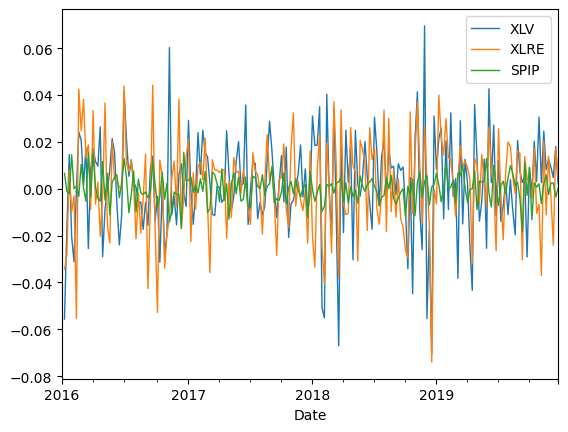

In [27]:
rets.loc["2016":"2019", ["XLV", "XLRE", "SPIP"]].plot(linewidth=1)

In [28]:
cols = ["XLV", "XLRE", "SPIP"]
dgps = [(column, rets[column].dropna().values) for column in cols]

In [29]:
rows = []
for name, dgp in dgps:
    res = hierarchical_analysis(dgp, name=name)
    #res["true_spec"] = expected[name]
    #res["match"]     = res["final_spec"] == expected[name]
    rows.append(res)

df = pd.DataFrame(rows)

# show transposed for readability (one column per series)
print("\n=== Hierarchical diagnostics (one column per series) ===\n")
print(df.set_index("series").T.to_string())
print("\n=== Summary ===\n")
print(df[["series", "final_spec"]].to_string(index=False))


=== Hierarchical diagnostics (one column per series) ===

series                                XLV                         XLRE                         SPIP
S1_LB_ret_p                        0.0131                       0.0087                       0.0096
S1_AR?                               True                         True                         True
S2_ARCH_LM_p                          0.0                          0.0                          0.0
S2_GARCH?                            True                         True                         True
S3_JB_p                               0.0                          0.0                          0.0
S3_skew_p                          0.0001                          0.0                          0.0
S3_skewness                        -0.446                       -0.489                       -0.538
S3_exkurt                           1.509                        1.496                        2.406
S3_innov                           Skew-t

In [30]:
models = []
for model_desc in df['final_spec']:
    if 'Const' in model_desc:
        models.append(GARCH11Model())
    elif 'AR(1)' in model_desc:
        if 'Normal' in model_desc:
            models.append(AR1GARCH11NormalModel())
        elif 'Student-t' in model_desc:
            models.append(AR1GARCH11SymmModel())
        elif 'Skew-t' in model_desc:
            models.append(AR1GARCH11Model())
        else:
            print(f"unknown {model_desc}")
    else:
        print(f"unknown {model_desc}")
        
models

[AR1GARCH11Model(), AR1GARCH11Model(), AR1GARCH11Model()]

In [31]:
def get_PSR(series, model, params, sr_null = 0.0):
    sr_h = series.mean() / series.std(ddof=1)
    avar = model.avar(sr_h, **params)
    psr = norm.cdf((sr_h-sr_null)/np.sqrt(avar/len(series)))
    return psr

In [32]:
model_classes = [
    IIDNormalModel, 
    AR1NonNormalModel, 
    GARCH11Model, 
    AR1GARCH11Model
]

sr_null = 0.00

for name, series in dgps:
    for model_cls in model_classes:
        model = model_cls()
        params = model.fit(series)
        psr = get_PSR(series, model, params, sr_null=sr_null)
        print(f"{name:<10} {model.short_name:<18} {psr*100:10.4f}%")

XLV        iid_normal            95.7996%
XLV        ar1_nonnormal         96.9516%
XLV        garch11               94.9353%
XLV        ar1_garch11           96.2163%
XLRE       iid_normal            76.5149%
XLRE       ar1_nonnormal         79.8892%
XLRE       garch11               76.1354%
XLRE       ar1_garch11           78.7168%
SPIP       iid_normal            42.8805%
SPIP       ar1_nonnormal         42.1993%
SPIP       garch11               42.7957%
SPIP       ar1_garch11           42.2063%


In [41]:
model_classes = [
    AR1GARCH11Model
]

sr_null = 0.00
resids = {}

for name, series in dgps:
    for model_cls in model_classes:
        model = model_cls()
        params = model.fit(series, ret_res=True)
        print(name)
        res = params["fit_res"]
        print(res)
        resids[name] = res.std_resid
        psr = get_PSR(series, model, params, sr_null=sr_null)
        print(f"{name:<10} {model.short_name:<18} {psr*100:10.4f}%")

XLV
                                 AR - GARCH Model Results                                
Dep. Variable:                                 y   R-squared:                       0.010
Mean Model:                                   AR   Adj. R-squared:                  0.008
Vol Model:                                 GARCH   Log-Likelihood:               -1119.70
Distribution:      Standardized Skew Student's t   AIC:                           2253.40
Method:                       Maximum Likelihood   BIC:                           2283.19
                                                   No. Observations:                  521
Date:                           Tue, Jun 02 2026   Df Residuals:                      519
Time:                                   10:21:42   Df Model:                            2
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
------------------------------------

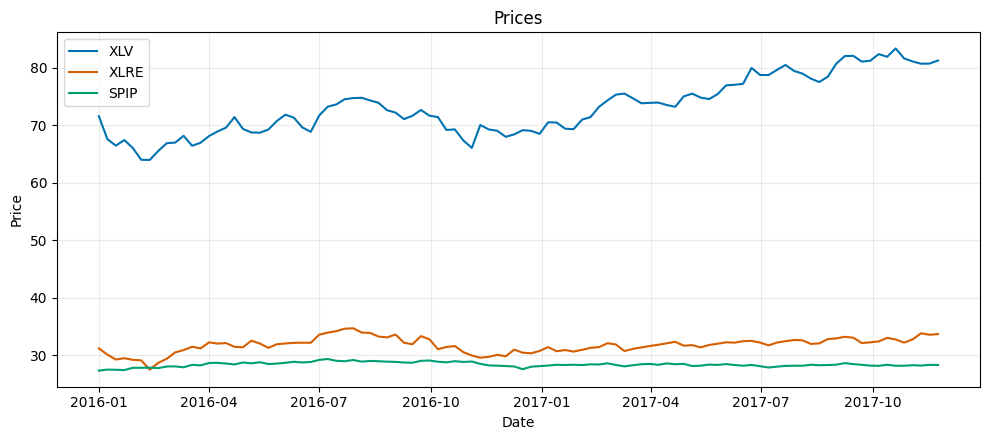

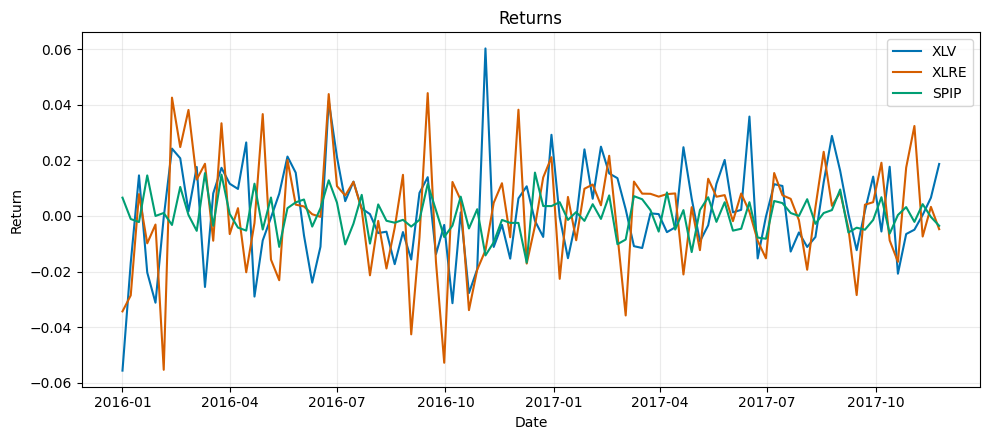

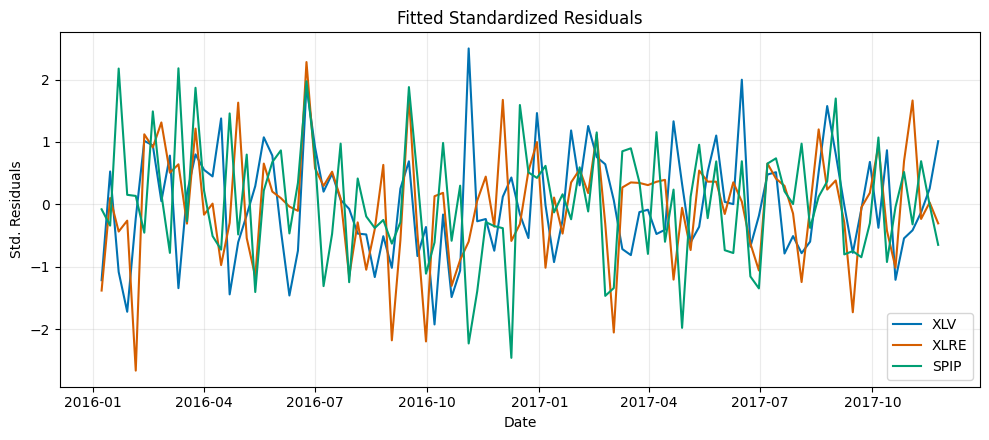

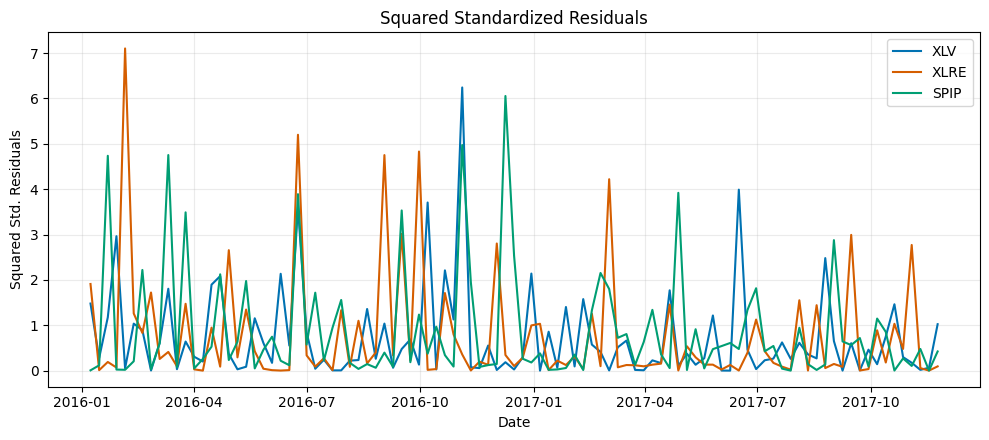

In [69]:
import matplotlib.pyplot as plt
from config import PLOTS_DIR

n = 100
indices = prices.index[0:n]

# ==========================================
# PLOT CONFIGURATION VARIABLES
# ==========================================
FIG_SIZE = (10, 4.5)
LINE_WIDTH = 1.5
X_LABEL = 'Date'
GRID_ALPHA = 0.25
path = PLOTS_DIR / "empirical"
path.mkdir(parents=True, exist_ok=True)

# Modern, colorblind-friendly palette
COLORS = {
    dgps[0][0]: '#0072B2',  # Deep Blue
    dgps[1][0]: '#D55E00',  # Vermillion (Burnt Orange)
    dgps[2][0]: '#009E73'   # Bluish Green
}
# ==========================================

# -------------------------------
# 1. Prices Plot
# -------------------------------
plt.figure(figsize=FIG_SIZE)
for name, series in dgps:
    plt.plot(indices, prices.loc[indices, name], label=name, color=COLORS[name], linewidth=LINE_WIDTH)
plt.title('Prices')
plt.xlabel(X_LABEL)
plt.ylabel('Price')
plt.legend()
plt.grid(True, alpha=GRID_ALPHA)
plt.tight_layout()
plt.savefig(path / 'prices.png', dpi=300, bbox_inches='tight')
plt.show() # Clears the figure from memory

# -------------------------------
# 2. Returns Plot
# -------------------------------
plt.figure(figsize=FIG_SIZE)
for name, series in dgps:
    plt.plot(indices, series[0:n], label=name, color=COLORS[name], linewidth=LINE_WIDTH)
plt.title('Returns')
plt.xlabel(X_LABEL)
plt.ylabel('Return')
plt.legend()
plt.grid(True, alpha=GRID_ALPHA)
plt.tight_layout()
plt.savefig(path / 'returns.png', dpi=300, bbox_inches='tight')
plt.show()


# -------------------------------
# 3. Standardized Residuals Plot
# -------------------------------
plt.figure(figsize=FIG_SIZE)
for name, series in dgps:
    plt.plot(indices, resids[name][0:n], label=name, color=COLORS[name], linewidth=LINE_WIDTH)
plt.title('Fitted Standardized Residuals')
plt.xlabel(X_LABEL)
plt.ylabel('Std. Residuals')
plt.legend()
plt.grid(True, alpha=GRID_ALPHA)
plt.tight_layout()
plt.savefig(path / 'residuals.png', dpi=300, bbox_inches='tight')
plt.show()

# -------------------------------
# 4. Squared Standardized Residuals Plot
# -------------------------------
plt.figure(figsize=FIG_SIZE)
for name, series in dgps:
    plt.plot(indices, resids[name][0:n]**2, label=name, color=COLORS[name], linewidth=LINE_WIDTH)
plt.title('Squared Standardized Residuals')
plt.xlabel(X_LABEL)
plt.ylabel('Squared Std. Residuals')
plt.legend()
plt.grid(True, alpha=GRID_ALPHA)
plt.tight_layout()
plt.savefig(path / 'sq_residuals.png', dpi=300, bbox_inches='tight')
plt.show()